# AUTOMOBILE MILEAGE PREDICTION
This workbook demonstrates use of **Test-train split** toward automobile mileage prediction.

In [1]:
# import necessary packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
# fetch data from URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

cols = [
            "mpg","cylinders","displacement","horsepower",
            "weight","acceleration","model_year","origin","car_name"
        ]

auto_df = pd.read_csv(url, delim_whitespace=True, comment='\t', na_values='?', names=cols)
auto_df.head()


/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_89666/2641810245.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto_df = pd.read_csv(url, delim_whitespace=True, comment='\t', na_values='?', names=cols)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
auto_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [4]:
auto_df.shape

(398, 9)

Observations, 
1. 398 entries is considered `moderate` from ML point of view.

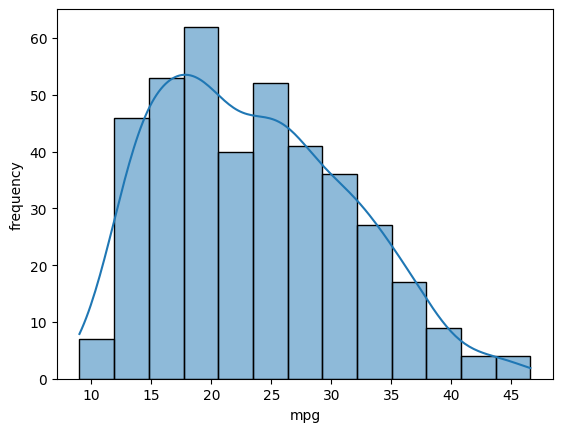

In [7]:
# check target distribution
sns.histplot(data=auto_df,x='mpg',kde=True)
plt.xlabel('mpg')
plt.ylabel('frequency')
plt.show()

Observations, 
1. `MPG` distribution does not indicate heavy `skewness` either `left`/`right`. It looks nearly `normal`.

### CHECK RELATIONSHIP OF TARGET WITH NUMERICAL ATTRIBUTES
Below we compute `Pearson correlation coefficient` that measures `Linear relationship` between `target` & each of the other attributes.

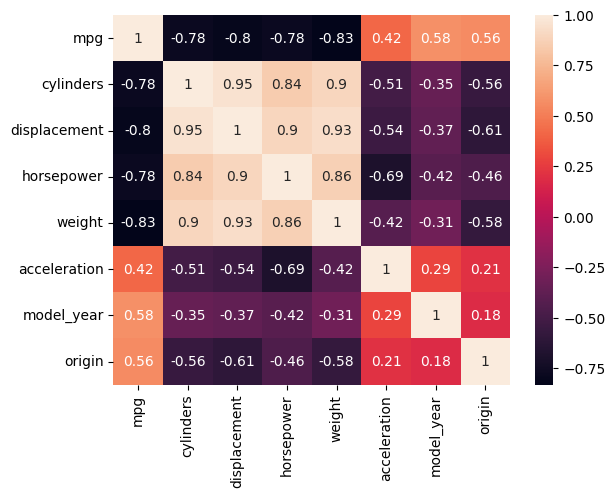

In [10]:
num_cols = auto_df.select_dtypes(include='number').columns

# compute pearson correlation coeff across numerical columns
corr_result = auto_df[num_cols].corr()

# display correlation with heatmap
sns.heatmap(corr_result,annot=True)
plt.show()

Observations, 
1. From above heatmap we find that there exists several features which dictates the `Target variable` such as **cylinders, displacement, horsepower & weight**. Hence stratification on just one feature wouldn't be helpful.

### SPLIT DATA INTO TRAIN AND TEST SET

In [75]:
# make a copy of the original dataframe
df = auto_df.copy()
cols = [
            "cylinders","displacement","horsepower",
            "weight","acceleration","model_year","origin","car_name"
        ]

# perform simple random sampling
train_set, test_set = train_test_split(df,random_state=42,test_size=0.2)
print(f'Train-size:{train_set.shape[0]}, Test-size:{test_set.shape[0]}')

Train-size:318, Test-size:80


## EDA
Below we perform **EDA (Exploratory Data Analysis)** on the **train-set** to check on the following, 
1. *Null* 
2. *Outliers* 
3. General distribution of data. 

If present handle those first. Next we perform *Feature Scaling* before feeding it to an *ML* model with *train-test* split for training and then prediction.

In [76]:
train_set.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
18,27.0,4,97.0,88.0,2130.0,14.5,70,3,datsun pl510
376,37.0,4,91.0,68.0,2025.0,18.2,82,3,mazda glc custom l
248,36.1,4,91.0,60.0,1800.0,16.4,78,3,honda civic cvcc
177,23.0,4,115.0,95.0,2694.0,15.0,75,2,audi 100ls


In [77]:
# check on null values
train_set.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      5
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

### IMPUTE NULL IN TRAIN AND TEST SETS

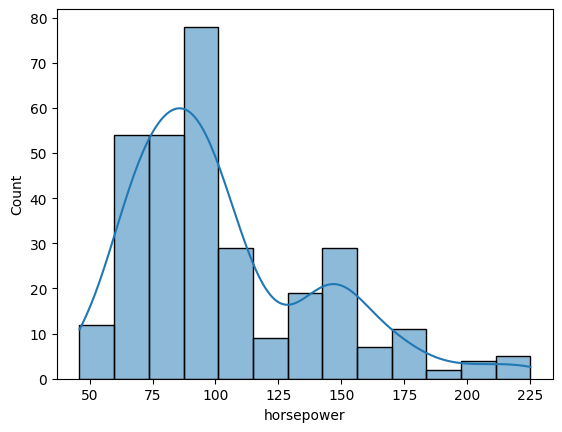

In [78]:
# plot distribution of horsepower
sns.histplot(data=train_set,x='horsepower',kde=True)
plt.show()

Observations, 
1. Distribution is `right-skewed` and `bi-modal`. 
2. Most cars fall within `60-100 hp` that come under `economy`. 
3. There is a secondary bump that indicates `mid-range` segment with higher horsepower between `130-160 hp`.
4. A small set of cars fall under `premium` category with maximum horsepower. 

We use `median` to impute null horsepower across different vehicle categories.

In [79]:
# find median horsepower across different car names. For NaN replace it with zeros.b
hp_carwise = train_set.groupby(['car_name'])['horsepower'].agg('median').replace(np.nan,0)
hp_carwise.head()

car_name
amc ambassador brougham    175.0
amc ambassador sst         150.0
amc concord                 90.0
amc concord dl               0.0
amc concord dl 6            90.0
Name: horsepower, dtype: float64

In [80]:
# sanity check for null values
hp_carwise.isna().sum()

np.int64(0)

In [81]:
# impute null horsepower with median value category-wise
train_set['horsepower'] = np.where(train_set['horsepower'].isna(),hp_carwise[train_set['car_name']],train_set['horsepower'])

In [82]:
# sanity check for presence of null.
train_set['horsepower'].isna().sum()

np.int64(0)

In [83]:
# impute NULLs in test set
test_set.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      1
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [84]:
# impute null horsepower in test set with median value category-wise and do a sanity check to verify.
test_set['horsepower'] = test_set['horsepower'].fillna(test_set['car_name'].map(hp_carwise))
test_set.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

### FINDING DISTRIBUTION OF TARGET WITH OTHER ATTRIBUTES

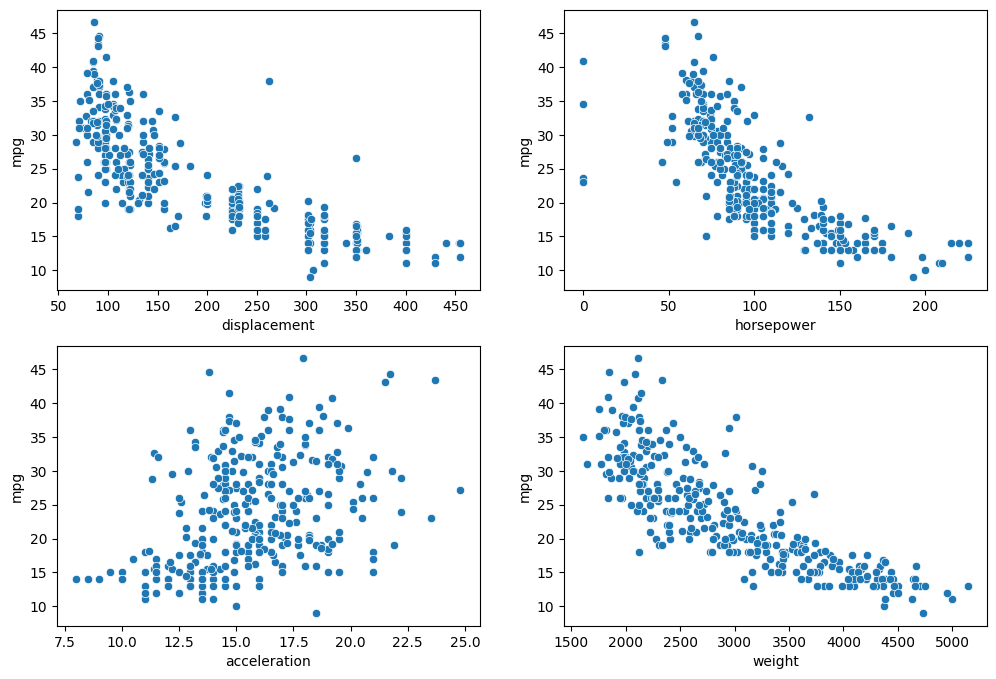

In [85]:
fig,axes = plt.subplots(2,2)
fig.set_size_inches(w=12,h=8)

# plot different distribution of target
sns.scatterplot(data=train_set,x='displacement',y='mpg',ax=axes[0,0])
sns.scatterplot(data=train_set,x='horsepower',y='mpg',ax=axes[0,1])
sns.scatterplot(data=train_set,x='acceleration',y='mpg',ax=axes[1,0])
sns.scatterplot(data=train_set,x='weight',y='mpg',ax=axes[1,1])
plt.show()

### EXTRACT MANUFACTURER INFORMATION FROM CAR NAME
Below we extract car manufacturer information from its name. The `Manufacturer` name is the first token present in the `car_name` attribute.

In [86]:
train_set['car_name'].unique()[:5]

array(['amc rebel sst', 'datsun pl510', 'mazda glc custom l',
       'honda civic cvcc', 'audi 100ls'], dtype=object)

In [87]:
# extract mfg name and store it as a seperate attribute
train_set['mfg'] = train_set['car_name'].str.split(' ', expand=True)[0]

In [88]:
# sanity check data to see if 'mfg' column is present
train_set.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mfg
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,amc
18,27.0,4,97.0,88.0,2130.0,14.5,70,3,datsun pl510,datsun
376,37.0,4,91.0,68.0,2025.0,18.2,82,3,mazda glc custom l,mazda
248,36.1,4,91.0,60.0,1800.0,16.4,78,3,honda civic cvcc,honda
177,23.0,4,115.0,95.0,2694.0,15.0,75,2,audi 100ls,audi


In [89]:
train_set['mfg'].unique()

array(['amc', 'datsun', 'mazda', 'honda', 'audi', 'pontiac', 'ford',
       'toyota', 'mercury', 'chrysler', 'opel', 'renault', 'plymouth',
       'dodge', 'chevrolet', 'volkswagen', 'buick', 'fiat', 'peugeot',
       'maxda', 'subaru', 'mercedes-benz', 'oldsmobile', 'bmw', 'saab',
       'triumph', 'vw', 'volvo', 'chevy', 'capri', 'hi', 'mercedes',
       'vokswagen', 'cadillac', 'chevroelt'], dtype=object)

Observations, 
1. From above we notice that several `mfg` names since spelled differently occurs multiple times and hence needs correction. Eg: Both **vw** & **volkswagen** are same but appear differently etc.

In [95]:
mfg_dict = {
    'vw':'volkswagen',
    'chevroelt':'chevrolet',
    'vokswagen':'volkswagen',
    'maxda':'mazda',
    'chevy':'chevrolet'
}

# replace only mfg names in the keys above by its corresponding values.
train_set['mfg'] = train_set['mfg'].replace(mfg_dict)

In [96]:
# sanity check to see if values are substituted.
train_set['mfg'].unique()

array(['amc', 'datsun', 'mazda', 'honda', 'audi', 'pontiac', 'ford',
       'toyota', 'mercury', 'chrysler', 'opel', 'renault', 'plymouth',
       'dodge', 'chevrolet', 'volkswagen', 'buick', 'fiat', 'peugeot',
       'subaru', 'mercedes-benz', 'oldsmobile', 'bmw', 'saab', 'triumph',
       'volvo', 'capri', 'hi', 'mercedes', 'cadillac'], dtype=object)

In [97]:
# extract mfg name and store it as a seperate attribute in test set
test_set['mfg'] = test_set['car_name'].str.split(' ', expand=True)[0]

# replace values
test_set['mfg'] = test_set['mfg'].replace(mfg_dict)

# sanity check on test set for successful replacement
test_set['mfg'].unique()

array(['honda', 'ford', 'amc', 'plymouth', 'toyota', 'chrysler',
       'oldsmobile', 'chevrolet', 'dodge', 'pontiac', 'volvo', 'mazda',
       'volkswagen', 'fiat', 'cadillac', 'datsun', 'mercury', 'audi',
       'toyouta', 'nissan', 'saab', 'peugeot', 'buick'], dtype=object)

Observations, 
1. Even with `manufacturer` extracted in train-set we see there exists a high cardinality. Hence we perform `out-of-fold target encoding` to encode categorical features in `mfg`. 
2. We drop the column `car_name`.

In [101]:
from sklearn.model_selection import StratifiedKFold

In [108]:
# out-of-fold target encoding for 'mfg' attribute
def target_encoding(train_df: pd.DataFrame, test_df: pd.DataFrame):
    '''
    Function that performs OOF CV for Target encoding. It performs mean encoding in case of train set
    and for test set depending upon mfg replaces mean of target encoding for each mfg.

    In the event during encoding of train set if there exists a mfg category in validation fold absent across all train folds
    the corresponding target encoded value is set to zero.

    For test set in case there exists null value it's replaced with zero.
    '''

    skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

    # make copies of train & test sets
    train_df = train_df.copy()
    test_df = test_df.copy()

    # set attribute to store encoded values
    train_df['mfg_te'] = np.nan
    test_df['mfg_te'] = np.nan

    for tr_idx, val_idx in skf.split(train_df, train_df['mpg']):
        X_train, X_val = train_df.iloc[tr_idx], train_df.iloc[val_idx]
        
        # leakage-free target encode
        mfg_wise_target_encoding = X_train.groupby(['mfg'])['mpg'].agg('mean')
        train_df.loc[val_idx,'mfg_te'] = X_val['mfg'].map(mfg_wise_target_encoding).fillna(0)
    
    # encode test set using mean of mfg-wise target encoding. Null values are replaced by zero.
    train_mfg_mean_target_encoding = train_df.groupby(['mfg'])['mfg_te'].agg('mean')
    test_df['mfg_te'] = test_df['mfg'].map(train_mfg_mean_target_encoding).fillna(0)

    return train_df,test_df

In [113]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 318 entries, 3 to 102
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           318 non-null    float64
 1   cylinders     318 non-null    int64  
 2   displacement  318 non-null    float64
 3   horsepower    318 non-null    float64
 4   weight        318 non-null    float64
 5   acceleration  318 non-null    float64
 6   model_year    318 non-null    int64  
 7   origin        318 non-null    int64  
 8   car_name      318 non-null    object 
 9   mfg           318 non-null    object 
dtypes: float64(5), int64(3), object(2)
memory usage: 27.3+ KB


In [114]:
# seperate predictors and labels from both train and test sets
y_train = train_set.pop('mpg')
X_train = train_set

y_test = test_set.pop('mpg')
X_test = test_set

### SETUP DATA TRANSFORMATION PIPELINE

In [131]:
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [111]:
def frequency_encoding(X:np.array):
    '''
    Fucntion that performs frequency encoding for mfg attribute.
    '''
    # convert numpy array (n,1) to series (n,)
    X_series = pd.Series(X.flatten())

    # compute frequency and normalize it
    freq = X_series.value_counts(normalize=True)

    # frequency encode
    encoded = X_series.map(freq)

    # return 2D-array (n,1)
    return encoded.to_numpy().reshape(-1,1)

In [117]:
num_pipeline = make_pipeline(
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    FunctionTransformer(frequency_encoding,validate=False)      # Function transformers usually expect input to be of numeric type in the form of array.In the event of string input validation may fail.
)

# column transformer always convert input -> numpy array.
preprocessing = make_column_transformer(
    (num_pipeline,make_column_selector(dtype_include='number')),
    (cat_pipeline,['mfg']),
    remainder='drop'
)

### BASIC LINEAR REGRESSION
Below we feed preprocessed data to a **Linear Regression** model for training and prediction. 

We make use of **R2 score** to evaluate model performance. **R2** compares model performance with that of performance if only **mean of the test labels** were used as predicted labels. 

Usually:
* **R2** < 0 => Worse model
* **R2** = 0 => Same as predicting mean
* **R2** = 1 => perfect model.

In [135]:
# setup model pipeline: preprocessing data -> feed preprocessed data to model
lin_reg_pipeline = make_pipeline(preprocessing,LinearRegression())

# train model
lin_reg_pipeline.fit(X_train,y_train)

# make predictions on train and test
y_predict_tr = lin_reg_pipeline.predict(X_train)
y_predict_ts = lin_reg_pipeline.predict(X_test)

In [136]:
# compute performance on train set
r2_result_train = r2_score(y_train,y_predict_tr)
print(f'R2-score on train: {r2_result_train}')

R2-score on train: 0.8166999326512406


In [137]:
# compute r2-score & mse loss on test set
r2_result_test = r2_score(y_test,y_predict_ts)
print(f'R2_score on test: {r2_result_test}')

R2_score on test: 0.8484278234670063


In [138]:
# measure performance using kfold cv
lin_reg_r2_scores = cross_val_score(lin_reg_pipeline,X_train,y_train,cv=5,scoring='r2')
print(f'5-fold CV performance has R2_scores mean: {lin_reg_r2_scores.mean()} & R2_scores std:{lin_reg_r2_scores.std()}')

5-fold CV performance has R2_scores mean: 0.7940618830522543 & R2_scores std:0.026601157005127565
